# Demonstração: Análise de curvas de luz Ultravioleta
## Dados XMM-Newton

https://nxsa.esac.esa.int/nxsa-web/#search

Selecionamos na base de dados a Estrela que estamos observando e queremos baixar os dados. 
Depois selecionamos os dados de interesse de acordo com a análise a ser feita. 

_No caso do presente projeto, realizamos o download de curvas de luz que apresentaram trânsito_

In [3]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

## Importando arquivos e analisando dados
Lembre-se de mudar o path para o que se refere ao local do seu computador onde os dados foram baixados

### IMPORTANTE: EDITE os parths LINHA COM O CAMINHO PARA A SUA PASTA 
### Exemplo no Windows: `'C:/Usuarios/Beatriz/Downloads/dados_xmm'`
### Exemplo no Mac/Linux: `'/Users/beatrizduque/Downloads/Mestrado/HD189733/dados'`

In [10]:
fits_file = "/Users/beatrizduque/Downloads/Mestrado/HD189733/lightcurves/0506070201-3/1347_0506070201/1347_0506070201_M1S00100AUX.FIT"

hdul = fits.open(fits_file)
data = hdul['M1AUX1'].data

In [9]:
hdul[0].header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                    8 / number of bits per data pixel                  
NAXIS   =                    0 / number of data axes                            
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format defined in Astronomy and
COMMENT   Astrophysics Supplement Series v44/p363, v44/p371, v73/p359, v73/p365.
COMMENT   Contact the NASA Science Office of Standards and Technology for the   
COMMENT   FITS Definition document #100 and other FITS information.             
ORIGIN  = 'XMM-SOC '           / Processing site                                
DATE    = '2007-04-17T14:07:27' / File creation date                            
FILENAME= '1347_0506070201_M1S00100AUX.FIT' / Filename                          
CREATOR = 'PMS/ODF V2.12'      / FITS generated code                            
CATEGORY= 'XMMODF  '        

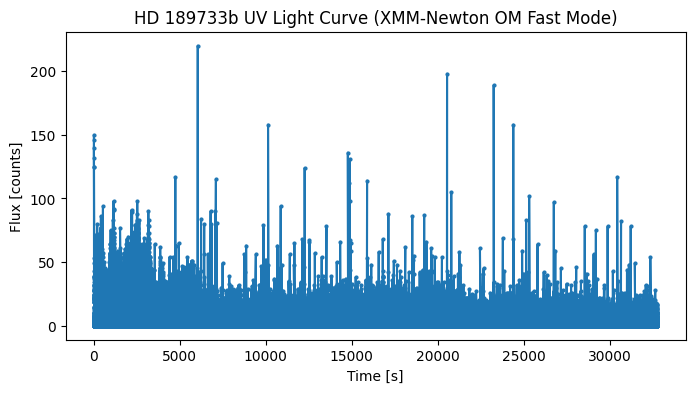

In [11]:
# Construct time (seconds)
time = data['FTCOARSE'] + data['FTFINE']*1e-3  # FTFINE is usually in ms

# Flux (counts)
flux = data['NVALID']

# Plot
plt.figure(figsize=(8,4))
plt.plot(time, flux, 'o-', markersize=2)
plt.xlabel("Time [s]")
plt.ylabel("Flux [counts]")
plt.title("HD 189733b UV Light Curve (XMM-Newton OM Fast Mode)")
plt.show()

### Analisando a estrutura do arquivo

In [25]:
# O path do arquivo do XMM-Newton que queremos investigar
nome_arquivo_fits = '/Users/beatrizduque/Downloads/Mestrado/HD189733/lightcurves/0506070201-3/1347_0506070201_SCX00000TCS.FIT'

print(f"--- Iniciando a inspeção do arquivo: {nome_arquivo_fits} ---\n")

try:
    with fits.open(nome_arquivo_fits) as hdul:
        
        # O método .info() nos dá um resumo rápido da estrutura.
        print("--- Resumo da Estrutura (hdul.info()) ---")
        hdul.info()
        print("\n" + "="*50 + "\n")

        # Agora, vamos olhar em detalhe cada uma das 'extensões' (HDUs).
        for i, hdu in enumerate(hdul):
            print(f"--- Detalhes da Extensão (HDU) número {i} ---")
            
            # Imprime o cabeçalho completo.
            print("\n[CABEÇALHO (HEADER)]")
            print(repr(hdu.header))
            
            # Verifica se a extensão tem dados.
            if hdu.data is not None:
                print("\n[DADOS ENCONTRADOS NESTA EXTENSÃO]")
                if hasattr(hdu.data, 'columns'):
                    print("Nomes das colunas:", hdu.data.columns.names)
                else:
                    print("Formato dos dados (shape):", hdu.data.shape)
            else:
                print("\n[SEM DADOS NESTA EXTENSÃO]")

            print("\n" + "="*50 + "\n")

except FileNotFoundError:
    print(f"ERRO: Arquivo '{nome_arquivo_fits}' não encontrado.")
except Exception as e:
    print(f"Ocorreu um erro inesperado: {e}")

--- Iniciando a inspeção do arquivo: /Users/beatrizduque/Downloads/Mestrado/HD189733/lightcurves/0506070201-3/1347_0506070201_SCX00000TCS.FIT ---

--- Resumo da Estrutura (hdul.info()) ---
Filename: /Users/beatrizduque/Downloads/Mestrado/HD189733/lightcurves/0506070201-3/1347_0506070201_SCX00000TCS.FIT
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      15   ()      
  1  SCTCS1      1   BinTableHDU     54   2887R x 12C   [1J, 1J, 1I, 1I, 1J, 1I, 39A, 39A, 1I, 27A, 5A, 27A]   


--- Detalhes da Extensão (HDU) número 0 ---

[CABEÇALHO (HEADER)]
SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                    8 / number of bits per data pixel                  
NAXIS   =                    0 / number of data axes                            
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format defined in Astronomy an

## Extração da curva de luz
Script para analisar e plotar a curva de luz do XMM-Newton/OM

In [ ]:
#/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps

Arquivo '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/P0506070201OMS007TIMESR1001.FTZ' lido com sucesso!
Total de 440 pontos de dados extraídos.


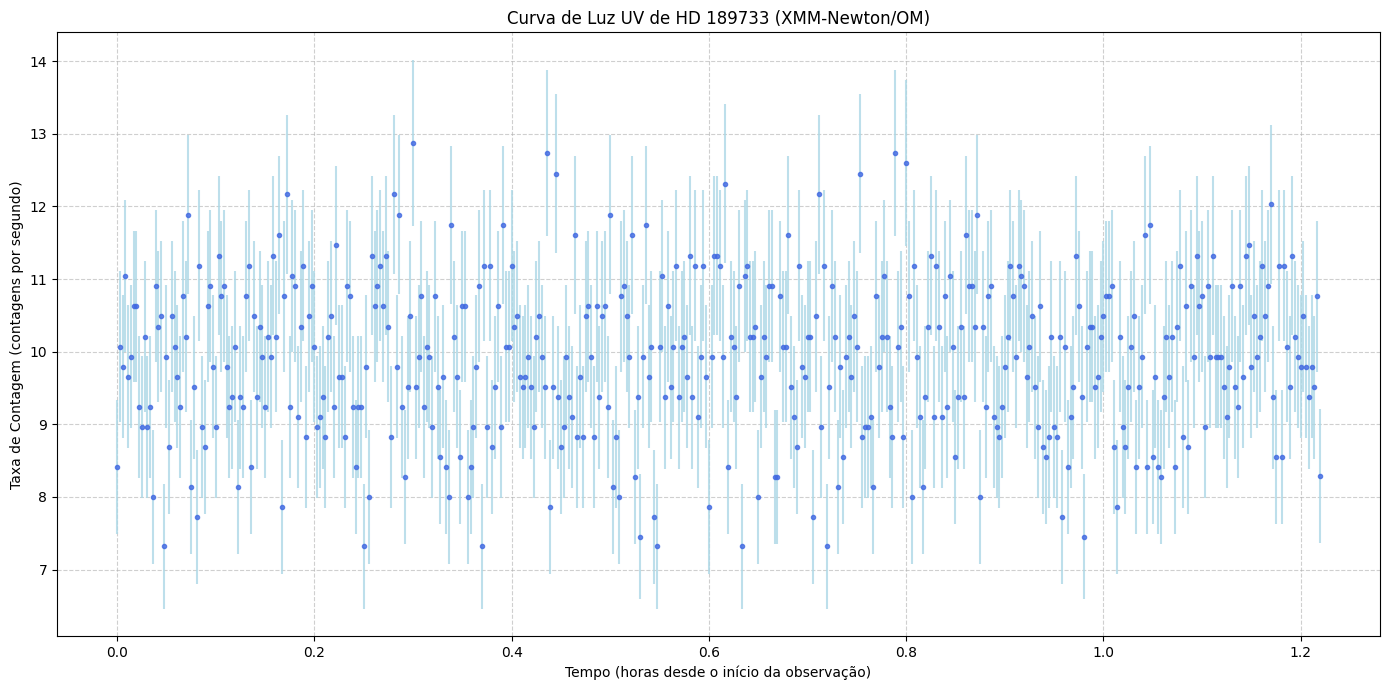

In [1]:
# --- PASSO 1: CONFIGURAÇÃO ---
# Nome do arquivo de curva de luz que você encontrou!
nome_arquivo_fits = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/P0506070201OMS007TIMESR1001.FTZ' 

# Nomes de coluna padrão para curvas de luz do XMM-Newton/OM.
coluna_tempo = 'TIME'
coluna_fluxo = 'RATE' # 'RATE' (taxa de contagens/segundo) é o fluxo
coluna_erro  = 'ERROR'

# --- PASSO 2: ABRIR O ARQUIVO E EXTRAIR OS DADOS ---
try:
    with fits.open(nome_arquivo_fits) as hdul:
        # A curva de luz está na primeira extensão de tabela (HDU 1)
        dados_tabela = hdul[1].data
        
        # Extrai os dados das colunas
        tempos = dados_tabela[coluna_tempo]
        fluxos = dados_tabela[coluna_fluxo]
        erros_fluxo = dados_tabela[coluna_erro]
        
        print(f"Arquivo '{nome_arquivo_fits}' lido com sucesso!")
        print(f"Total de {len(tempos)} pontos de dados extraídos.")

except FileNotFoundError:
    print(f"ERRO: Arquivo '{nome_arquivo_fits}' não encontrado.")
    print("Verifique se o nome do arquivo está correto e se ele está na mesma pasta do script.")
    exit()
except KeyError as e:
    print(f"ERRO: A coluna {e} não foi encontrada no arquivo.")
    print("Use o script 'inspecionar_fits.py' para ver os nomes corretos das colunas e ajuste o script, se necessário.")
    exit()

# --- PASSO 3: PLOTAR A CURVA DE LUZ ---
# Converte o tempo de segundos (padrão do XMM) para horas para melhor visualização
tempos_em_horas = (tempos - tempos[0]) / 3600.0

plt.figure(figsize=(14, 7))
plt.errorbar(tempos_em_horas, fluxos, yerr=erros_fluxo, fmt='o', markersize=3, color='royalblue', ecolor='lightblue', capsize=0, alpha=0.8)
plt.title('Curva de Luz UV de HD 189733 (XMM-Newton/OM)')
plt.xlabel('Tempo (horas desde o início da observação)')
plt.ylabel('Taxa de Contagem (contagens por segundo)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [1]:
nome_arquivo_fits = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/P0506070201OMS007TIMESR1001.FTZ' 

print(f"--- Iniciando a inspeção do arquivo: {nome_arquivo_fits} ---\n")

try:
    with fits.open(nome_arquivo_fits) as hdul:
        
        print("--- Resumo da Estrutura (hdul.info()) ---")
        hdul.info()
        print("\n" + "="*50 + "\n")

        # Vamos olhar em detalhe CADA extensão
        for i, hdu in enumerate(hdul):
            print(f"--- Detalhes da Extensão (HDU) número {i} ---")
            
            print("\n[CABEÇALHO (HEADER)]")
            print(repr(hdu.header))
            
            if hdu.data is not None:
                print("\n[DADOS ENCONTRADOS NESTA EXTENSÃO]")
                if hasattr(hdu.data, 'columns'):
                    print("Nomes das colunas:", hdu.data.columns.names)
            else:
                print("\n[SEM DADOS NESTA EXTENSÃO]")

            print("\n" + "="*50 + "\n")

except FileNotFoundError:
    print(f"ERRO: Arquivo '{nome_arquivo_fits}' não encontrado.")
except Exception as e:
    print(f"Ocorreu um erro inesperado: {e}")

--- Iniciando a inspeção do arquivo: /Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/P0506070201OMS007TIMESR1001.FTZ ---

--- Resumo da Estrutura (hdul.info()) ---
Filename: /Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/P0506070201OMS007TIMESR1001.FTZ
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      79   ()      
  1  RATE          1 BinTableHDU     75   440R x 5C   [D, E, E, E, E]   


--- Detalhes da Extensão (HDU) número 0 ---

[CABEÇALHO (HEADER)]
SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                    8 / number of bits per data pixel                  
NAXIS   =                    0 / number of data axes                            
EXTEND  =                    T / FITS dataset may contain extensions            
XPROC0  = 'omlcbuild srcregionset=intermediate/OMFastAnalyse-om-2-OM_Source_Re&'
CONTINUE  'gion_File-S00700

# Análise da janela de trânsito durante a curva de luz
Nem sempre a curva de luz detecta um trânsito 
É necessário calcular, de acordo com cada observação, o centro do trânsito

In [ ]:
from astropy.io import fits
from astropy.time import Time
import numpy as np

In [2]:
# --- 1. CONFIGURAÇÃO ---
# O nome do seu arquivo de curva de luz
nome_arquivo_fits = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/P0506070201OMS007TIMESR1001.FTZ' 

# Efemérides conhecidas para o HD 189733b (fonte: exoplanet.eu, Agol et al. 2010)
T0 = 2454279.43671  # Tempo do centro de um trânsito de referência (em BJD)
P = 2.21857567     # Período orbital do planeta (em dias)

# Duração do trânsito em dias (1.8 horas / 24 horas/dia)
duracao_transito_dias = 1.8 / 24.0

# --- 2. EXTRAIR DATA DA OBSERVAÇÃO (VERSÃO CORRIGIDA) ---
try:
    with fits.open(nome_arquivo_fits) as hdul:
        # CORREÇÃO: A data está no cabeçalho da primeira extensão (HDU 0)
        header = hdul[0].header
        
        # Pega a data de início da observação
        data_inicio_obs_str = header['DATE-OBS']
        
        # Converte a data para o formato de Data Juliana (JD)
        t_obs = Time(data_inicio_obs_str, format='isot', scale='utc')
        jd_obs = t_obs.jd
        
        print(f"Arquivo: {nome_arquivo_fits}")
        print(f"Data de início da observação encontrada: {data_inicio_obs_str} (UTC)")
        print(f"Isso corresponde a Data Juliana (JD): {jd_obs:.5f}")

except FileNotFoundError:
    print(f"ERRO: Arquivo '{nome_arquivo_fits}' não encontrado.")
    exit()
except KeyError:
    print("ERRO: Keyword 'DATE-OBS' não foi encontrada no cabeçalho da HDU 0.")
    exit()

# --- 3. CALCULAR A FASE ORBITAL ---
# A fórmula da fase calcula 'quantas órbitas se passaram' desde T0
# e pega apenas a parte fracionária (de 0.0 a 1.0)
fase = ((jd_obs - T0) / P) % 1.0

# O centro do trânsito ocorre, por definição, na fase 0.0 (ou 1.0)
# A fase de início do trânsito é ~ -duração/2
# A fase de fim do trânsito é ~ +duração/2
fase_metade_duracao = (duracao_transito_dias / P) / 2.0

# As fases são calculadas de 0 a 1. O trânsito acontece ao redor da fase 1.0/0.0
# Fase de início do trânsito (ex: 0.98)
fase_inicio_transito = 1.0 - fase_metade_duracao 
# Fase de fim do trânsito (ex: 0.02)
fase_fim_transito = fase_metade_duracao

print(f"\nPeríodo do planeta (P): {P} dias")
print(f"Época de referência (T0): {T0} JD")
print("-" * 40)
print(f"Fase orbital no início da observação: {fase:.4f}")
print(f"(Um trânsito acontece entre a fase ~{fase_inicio_transito:.4f} e ~{fase_fim_transito:.4f})")
print("-" * 40)

# --- 4. INTERPRETAR O RESULTADO ---
print("Análise:")
if fase > fase_inicio_transito or fase < fase_fim_transito:
    print(">>> RESULTADO: A observação começou DURANTE um trânsito!")
    if fase > 0.5:
        print("    (Especificamente, parece ter pego a segunda metade do trânsito - o egresso).")
    else:
        print("    (Especificamente, parece ter pego a primeira metade do trânsito - o ingresso).")
else:
    print(">>> RESULTADO: A observação ocorreu FORA de um trânsito.")

Arquivo: /Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/P0506070201OMS007TIMESR1001.FTZ
Data de início da observação encontrada: 2007-04-17T22:07:08.000 (UTC)
Isso corresponde a Data Juliana (JD): 2454208.42162

Período do planeta (P): 2.21857567 dias
Época de referência (T0): 2454279.43671 JD
----------------------------------------
Fase orbital no início da observação: 0.9907
(Um trânsito acontece entre a fase ~0.9831 e ~0.0169)
----------------------------------------
Análise:
>>> RESULTADO: A observação começou DURANTE um trânsito!
    (Especificamente, parece ter pego a segunda metade do trânsito - o egresso).


# Análise do trânsito na curva de luz

In [ ]:
import os
import glob
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

Arquivo '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/P0506070201OMS007TIMESR1001.FTZ' lido com sucesso!
Dados binados em 12 pontos.


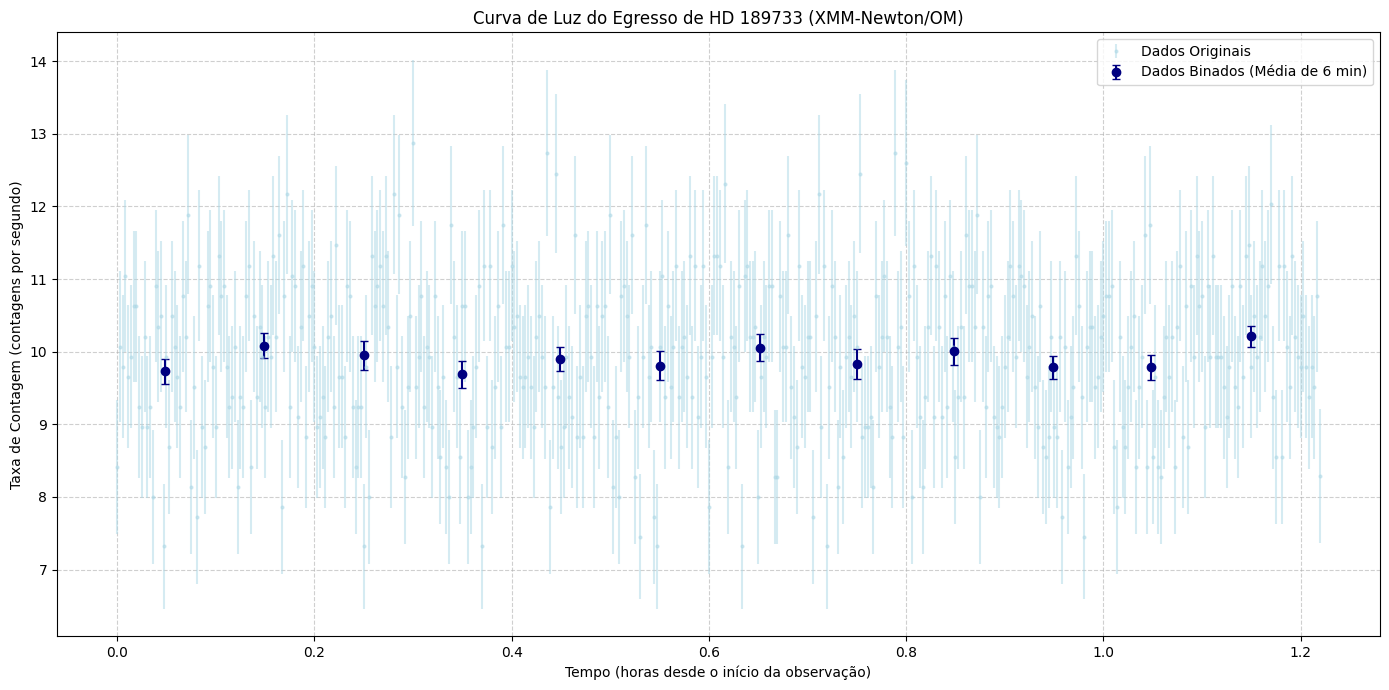

In [3]:
# --- PASSO 1: CONFIGURAÇÃO ---
coluna_tempo = 'TIME'
coluna_fluxo = 'RATE'
coluna_erro  = 'ERROR'

# --- PASSO 2: EXTRAIR OS DADOS ---
try:
    with fits.open(nome_arquivo_fits) as hdul:
        dados_tabela = hdul[1].data
        tempos = dados_tabela[coluna_tempo]
        fluxos = dados_tabela[coluna_fluxo]
        erros_fluxo = dados_tabela[coluna_erro]
        print(f"Arquivo '{nome_arquivo_fits}' lido com sucesso!")
except Exception as e:
    print(f"Ocorreu um erro: {e}")
    exit()

# Converte o tempo para horas
tempos_em_horas = (tempos - tempos[0]) / 3600.0

# --- PASSO 3: BINAR OS DADOS ---
# Vamos agrupar os dados em 'caixas' (bins) de 0.1 horas (6 minutos)
bin_size_horas = 0.1
bins = np.arange(tempos_em_horas.min(), tempos_em_horas.max(), bin_size_horas)

# Listas para guardar os dados binados
binned_time = []
binned_flux = []
binned_error = []

# Loop através de cada 'caixa' de tempo
for i in range(len(bins) - 1):
    # Encontra os pontos de dados que caem dentro desta 'caixa'
    mask = (tempos_em_horas >= bins[i]) & (tempos_em_horas < bins[i+1])
    
    # Se houver pontos na 'caixa', calcula a média
    if np.sum(mask) > 0:
        # O tempo do bin é o centro da 'caixa'
        binned_time.append(np.mean(tempos_em_horas[mask]))
        # O fluxo do bin é a média dos fluxos
        binned_flux.append(np.mean(fluxos[mask]))
        # O erro do bin é o erro padrão da média
        n_points = len(fluxos[mask])
        binned_error.append(np.std(fluxos[mask]) / np.sqrt(n_points))

print(f"Dados binados em {len(binned_time)} pontos.")

# --- PASSO 4: PLOTAR TUDO ---
plt.figure(figsize=(14, 7))

# Plota os dados originais, mais fracos, como fundo
plt.errorbar(tempos_em_horas, fluxos, yerr=erros_fluxo, fmt='.', markersize=4, color='lightblue', ecolor='lightblue', capsize=0, alpha=0.5, label='Dados Originais')

# Plota os dados BINADOS, mais fortes, por cima
plt.errorbar(binned_time, binned_flux, yerr=binned_error, fmt='o', markersize=6, color='navy', ecolor='navy', capsize=3, label='Dados Binados (Média de 6 min)')

plt.title('Curva de Luz do Egresso de HD 189733 (XMM-Newton/OM)')
plt.xlabel('Tempo (horas desde o início da observação)')
plt.ylabel('Taxa de Contagem (contagens por segundo)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Encontrados 10 arquivos de curva de luz do OM na pasta.
Processando arquivo: P0506070201OMS006TIMESR1001.FTZ
Processando arquivo: P0506070201OMS404TIMESR1001.FTZ
Processando arquivo: P0506070201OMS403TIMESR1001.FTZ
Processando arquivo: P0506070201OMS407TIMESR1001.FTZ
Processando arquivo: P0506070201OMS406TIMESR1001.FTZ
Processando arquivo: P0506070201OMS402TIMESR1001.FTZ
Processando arquivo: P0506070201OMS405TIMESR1001.FTZ
Processando arquivo: P0506070201OMS401TIMESR1001.FTZ
Processando arquivo: P0506070201OMS408TIMESR1001.FTZ
Processando arquivo: P0506070201OMS007TIMESR1001.FTZ

Processamento concluído. Total de 4400 pontos de dados combinados.


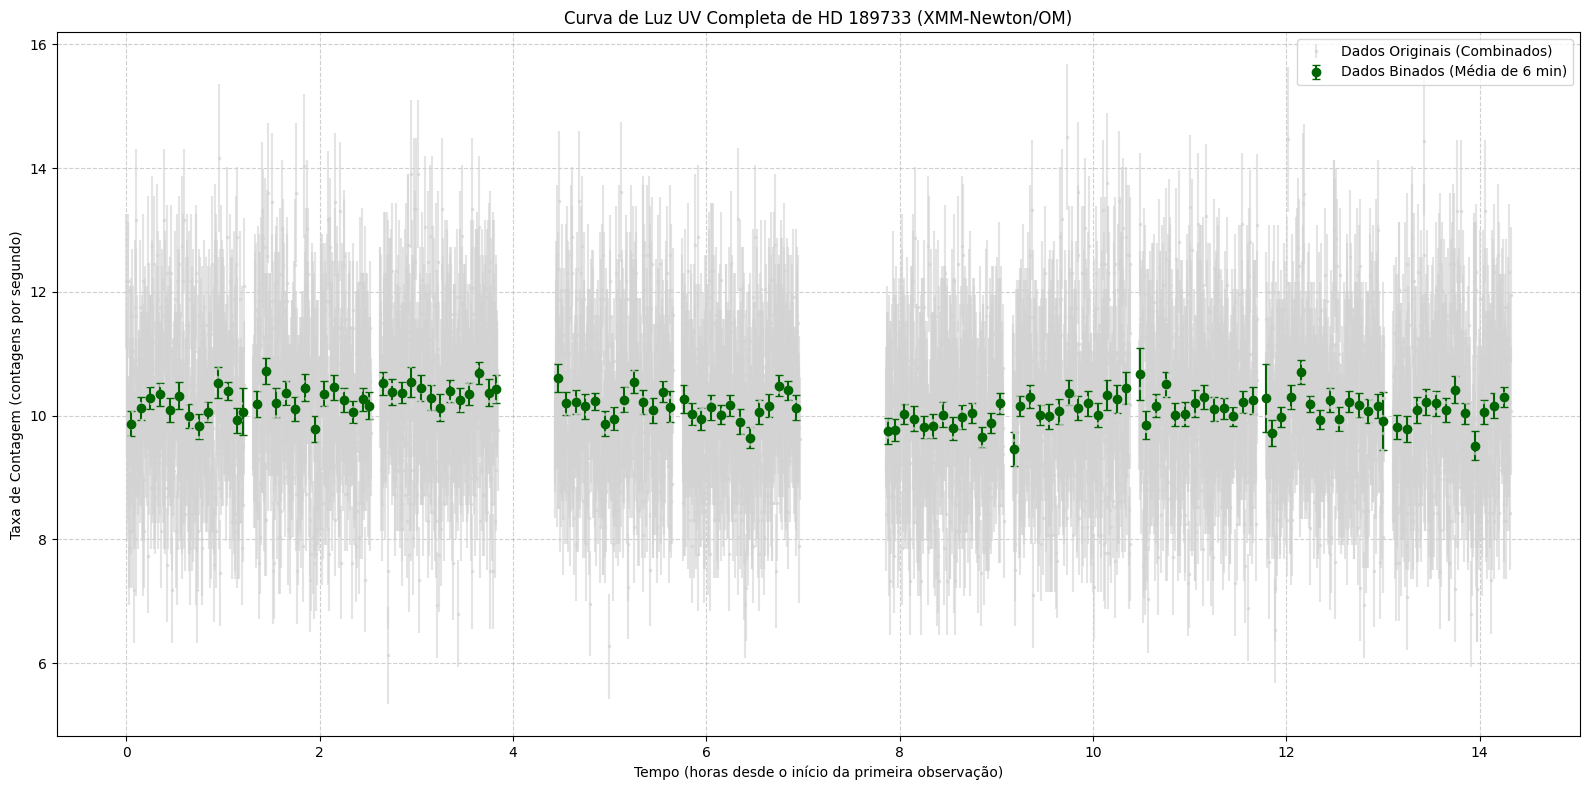

In [4]:
# --- PASSO 1: CONFIGURAÇÃO ---
pasta_dos_dados = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/'

# Padrão para encontrar apenas os arquivos de curva de luz do Optical Monitor (OM)
padrao_arquivo = '*OM*TIMESR*.FTZ'

# Nomes das colunas
coluna_tempo = 'TIME'
coluna_fluxo = 'RATE'
coluna_erro  = 'ERROR'

# --- PASSO 2: ENCONTRAR E PROCESSAR TODOS OS ARQUIVOS ---
# Cria o caminho completo para a busca
caminho_busca = os.path.join(pasta_dos_dados, padrao_arquivo)
lista_arquivos = glob.glob(caminho_busca)

# Listas para guardar todos os dados de todos os arquivos
todos_tempos = []
todos_fluxos = []
todos_erros = []

print(f"Encontrados {len(lista_arquivos)} arquivos de curva de luz do OM na pasta.")

# Loop para ler cada arquivo
for arquivo in lista_arquivos:
    try:
        print(f"Processando arquivo: {os.path.basename(arquivo)}")
        with fits.open(arquivo) as hdul:
            dados = hdul[1].data
            todos_tempos.extend(dados[coluna_tempo])
            todos_fluxos.extend(dados[coluna_fluxo])
            todos_erros.extend(dados[coluna_erro])
    except Exception as e:
        print(f"  -> Erro ao processar o arquivo {os.path.basename(arquivo)}: {e}")

if not todos_tempos:
    print("\nNenhum dado foi extraído. Verifique o caminho da pasta e o padrão do arquivo.")
    exit()

# --- PASSO 3: JUNTAR, ORDENAR E BINAR OS DADOS ---
# Converter listas para arrays numpy
todos_tempos = np.array(todos_tempos)
todos_fluxos = np.array(todos_fluxos)
todos_erros = np.array(todos_erros)

# Ordenar todos os dados cronologicamente
indices_ordenados = np.argsort(todos_tempos)
tempos_ordenados = todos_tempos[indices_ordenados]
fluxos_ordenados = todos_fluxos[indices_ordenados]
erros_ordenados = todos_erros[indices_ordenados]

print(f"\nProcessamento concluído. Total de {len(tempos_ordenados)} pontos de dados combinados.")

# Converter tempo para horas desde o início da PRIMEIRA observação
tempos_em_horas = (tempos_ordenados - tempos_ordenados[0]) / 3600.0

# Binning (exatamente como antes)
bin_size_horas = 0.1 # 6 minutos
bins = np.arange(tempos_em_horas.min(), tempos_em_horas.max(), bin_size_horas)
binned_time, binned_flux, binned_error = [], [], []

for i in range(len(bins) - 1):
    mask = (tempos_em_horas >= bins[i]) & (tempos_em_horas < bins[i+1])
    if np.sum(mask) > 0:
        binned_time.append(np.mean(tempos_em_horas[mask]))
        binned_flux.append(np.mean(fluxos_ordenados[mask]))
        n_points = len(fluxos_ordenados[mask])
        binned_error.append(np.std(fluxos_ordenados[mask]) / np.sqrt(n_points))

# --- PASSO 4: PLOTAR A CURVA DE LUZ COMPLETA ---
plt.figure(figsize=(16, 8))

plt.errorbar(tempos_em_horas, fluxos_ordenados, yerr=erros_ordenados, fmt='.', markersize=3, color='lightgray', ecolor='lightgray', capsize=0, alpha=0.6, label='Dados Originais (Combinados)')
plt.errorbar(binned_time, binned_flux, yerr=binned_error, fmt='o', markersize=6, color='darkgreen', ecolor='darkgreen', capsize=3, label=f'Dados Binados (Média de {bin_size_horas*60:.0f} min)')

plt.title('Curva de Luz UV Completa de HD 189733 (XMM-Newton/OM)')
plt.xlabel('Tempo (horas desde o início da primeira observação)')
plt.ylabel('Taxa de Contagem (contagens por segundo)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Corte de trânsitos e normalização das curvas

In [ ]:
import os
import glob
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

--------------------------------------------------
INICIANDO ANÁLISE DO TRÂNSITO
--------------------------------------------------
Fluxo médio fora do trânsito (linha de base): 10.1274 contagens/s
Fluxo normalizado estimado durante o trânsito: 0.9996
==> Profundidade do Trânsito estimada: 0.0004 ou 0.04%

Raio da estrela (Rs): 522,255 km
==> Raio do Planeta (Rp) estimado: 10,711 km
==> Isso equivale a aproximadamente 0.15 vezes o raio de Júpiter.
--------------------------------------------------


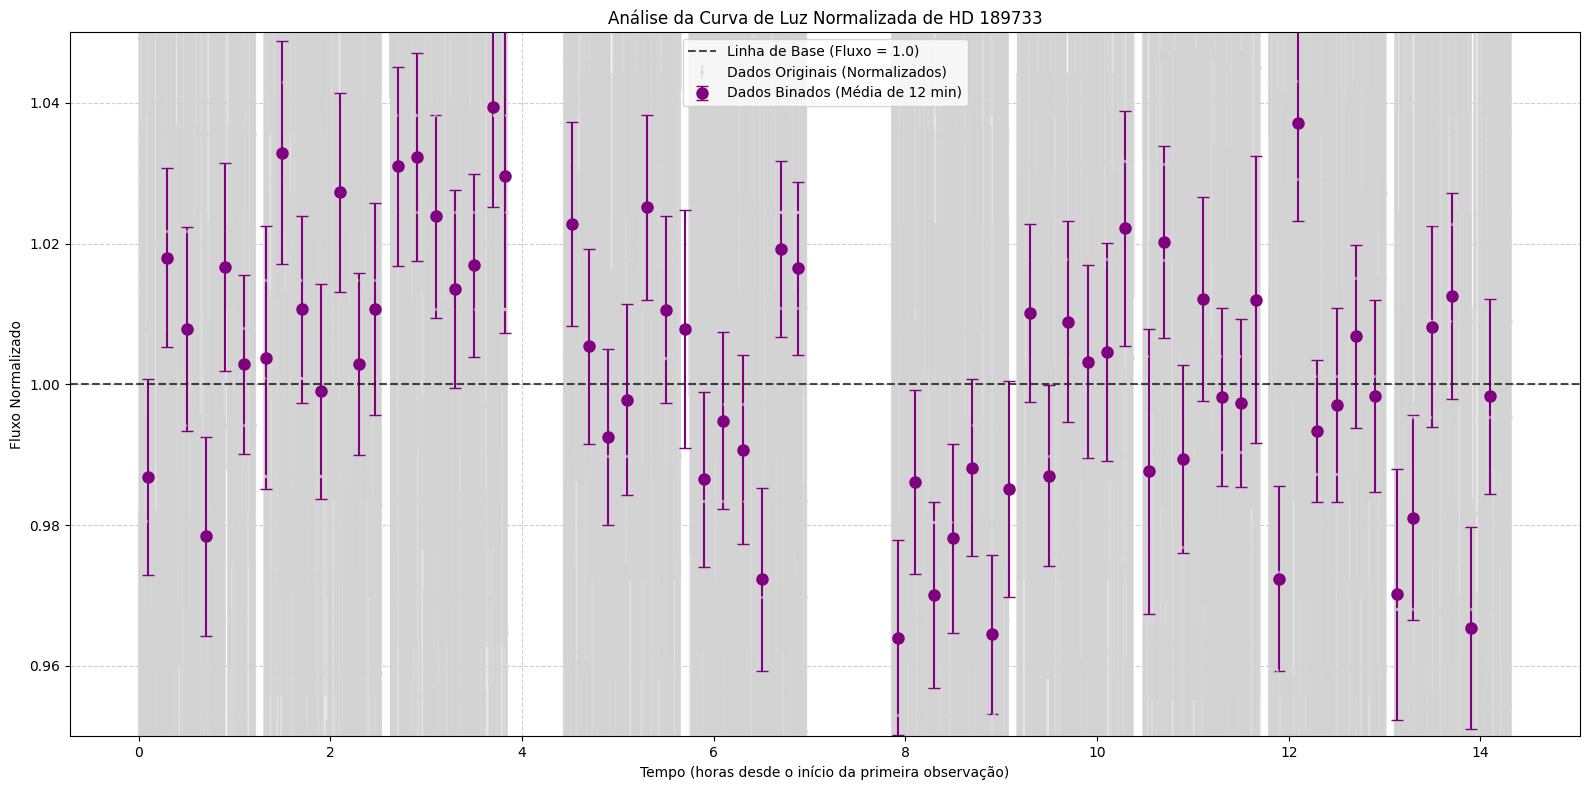

In [4]:
# --- 1. CONFIGURAÇÃO E EXTRAÇÃO DE DADOS (Como no script anterior) ---
pasta_dos_dados = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/'
padrao_arquivo = '*OM*TIMESR*.FTZ'
caminho_busca = os.path.join(pasta_dos_dados, padrao_arquivo)
lista_arquivos = glob.glob(caminho_busca)

todos_tempos, todos_fluxos, todos_erros = [], [], []
for arquivo in lista_arquivos:
    with fits.open(arquivo) as hdul:
        dados = hdul[1].data
        todos_tempos.extend(dados['TIME'])
        todos_fluxos.extend(dados['RATE'])
        todos_erros.extend(dados['ERROR'])

todos_tempos, todos_fluxos, todos_erros = np.array(todos_tempos), np.array(todos_fluxos), np.array(todos_erros)
indices_ordenados = np.argsort(todos_tempos)
tempos_ordenados = todos_tempos[indices_ordenados]
fluxos_ordenados = todos_fluxos[indices_ordenados]
tempos_em_horas = (tempos_ordenados - tempos_ordenados[0]) / 3600.0

# --- 2. ANÁLISE DO TRÂNSITO ---
print("-" * 50)
print("INICIANDO ANÁLISE DO TRÂNSITO")
print("-" * 50)

# Passo 1: Calcular o fluxo fora de trânsito e normalizar
mask_fora_transito = tempos_em_horas > 3.0
fluxo_fora_transito = np.mean(fluxos_ordenados[mask_fora_transito])
print(f"Fluxo médio fora do trânsito (linha de base): {fluxo_fora_transito:.4f} contagens/s")

# Normaliza todos os dados
fluxos_normalizados = fluxos_ordenados / fluxo_fora_transito
erros_normalizados = todos_erros[indices_ordenados] / fluxo_fora_transito

# Passo 2: Estimar a profundidade do trânsito
# Usaremos a média dos primeiros 20 minutos (1/3 de hora) para estimar o fluxo em trânsito
mask_em_transito = tempos_em_horas < (1/3)
fluxo_em_transito_norm = np.mean(fluxos_normalizados[mask_em_transito])
print(f"Fluxo normalizado estimado durante o trânsito: {fluxo_em_transito_norm:.4f}")

# A profundidade é 1 menos o fluxo normalizado em trânsito
profundidade = 1.0 - fluxo_em_transito_norm
print(f"==> Profundidade do Trânsito estimada: {profundidade:.4f} ou {profundidade*100:.2f}%")

# Passo 3: Calcular o raio do planeta
# Constantes
raio_estrela_em_raios_solares = 0.75
raio_sol_km = 696340
raio_jupiter_km = 69911

# Cálculo
raio_estrela_km = raio_estrela_em_raios_solares * raio_sol_km
raio_planeta_km = raio_estrela_km * np.sqrt(profundidade)
raio_planeta_em_raios_jupiter = raio_planeta_km / raio_jupiter_km

print(f"\nRaio da estrela (Rs): {raio_estrela_km:,.0f} km")
print(f"==> Raio do Planeta (Rp) estimado: {raio_planeta_km:,.0f} km")
print(f"==> Isso equivale a aproximadamente {raio_planeta_em_raios_jupiter:.2f} vezes o raio de Júpiter.")
print("-" * 50)

# --- 3. PLOTAR A CURVA DE LUZ NORMALIZADA ---
# Binning dos dados normalizados
bin_size_horas = 0.2
bins = np.arange(tempos_em_horas.min(), tempos_em_horas.max(), bin_size_horas)
binned_time, binned_flux, binned_error = [], [], []
for i in range(len(bins) - 1):
    mask = (tempos_em_horas >= bins[i]) & (tempos_em_horas < bins[i+1])
    if np.sum(mask) > 0:
        binned_time.append(np.mean(tempos_em_horas[mask]))
        binned_flux.append(np.mean(fluxos_normalizados[mask]))
        n_points = len(fluxos_normalizados[mask])
        binned_error.append(np.std(fluxos_normalizados[mask]) / np.sqrt(n_points))

plt.figure(figsize=(16, 8))
plt.errorbar(tempos_em_horas, fluxos_normalizados, yerr=erros_normalizados, fmt='.', markersize=3, color='lightgray', alpha=0.5, label='Dados Originais (Normalizados)')
plt.errorbar(binned_time, binned_flux, yerr=binned_error, fmt='o', markersize=8, color='purple', ecolor='purple', capsize=4, label=f'Dados Binados (Média de {bin_size_horas*60:.0f} min)')
plt.axhline(1.0, color='black', linestyle='--', alpha=0.7, label='Linha de Base (Fluxo = 1.0)')

plt.title('Análise da Curva de Luz Normalizada de HD 189733')
plt.xlabel('Tempo (horas desde o início da primeira observação)')
plt.ylabel('Fluxo Normalizado')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
# Ajusta o eixo Y para melhor visualização da profundidade
plt.ylim(0.95, 1.05)
plt.tight_layout()
plt.show()

--------------------------------------------------
JANELA DO TRÂNSITO (MEDIDA A PARTIR DOS DADOS)
Fim do egresso observado em: ~2.50 h
Início do trânsito inferido em: ~0.70 h
--------------------------------------------------


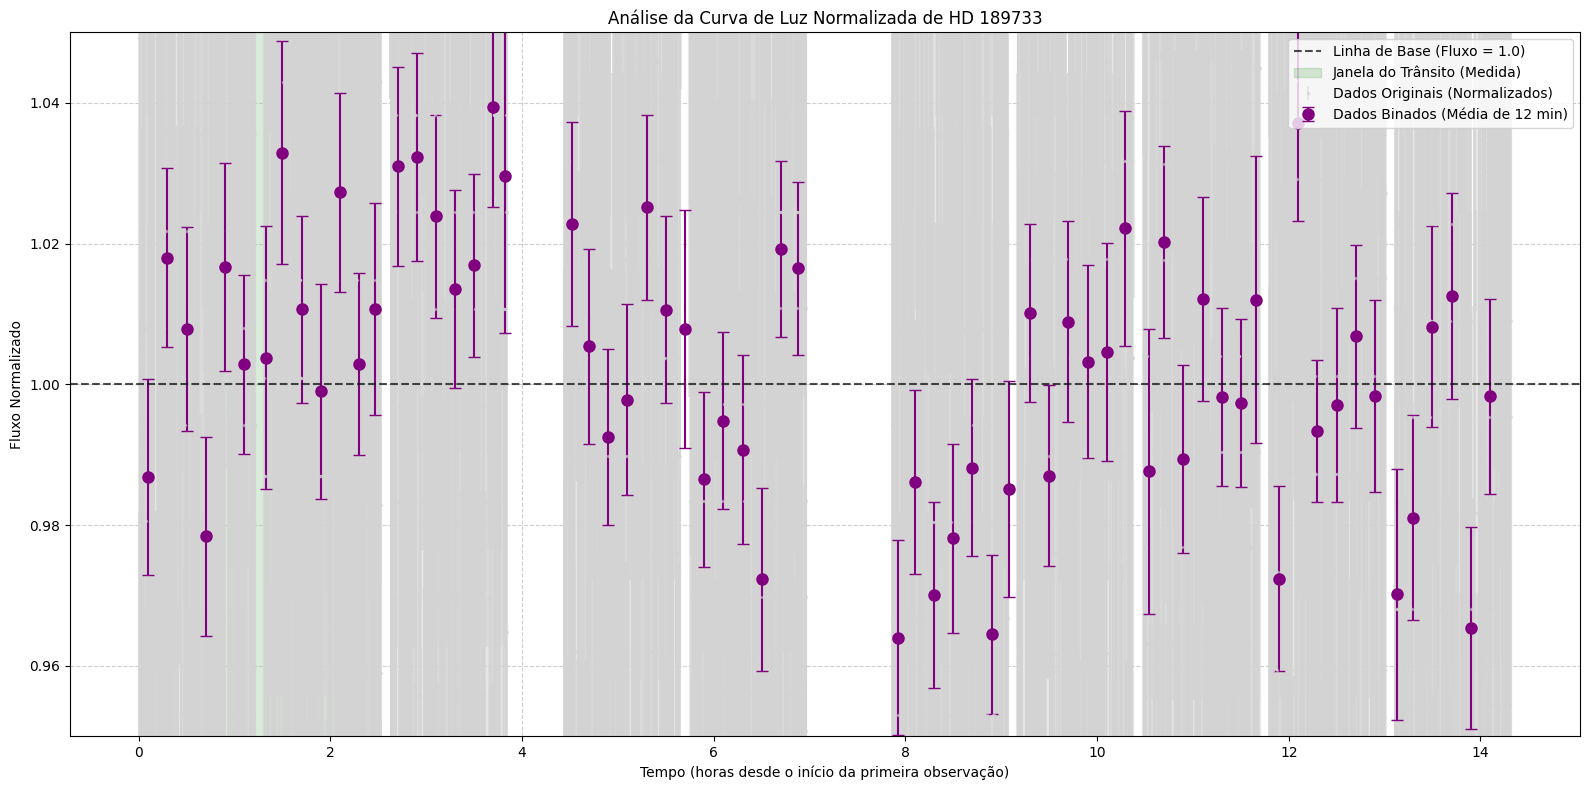

In [2]:
import os
import glob
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CONFIGURAÇÃO E EXTRAÇÃO DE DADOS (Sem alterações) ---
pasta_dos_dados = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/'
padrao_arquivo = '*OM*TIMESR*.FTZ'
caminho_busca = os.path.join(pasta_dos_dados, padrao_arquivo)
lista_arquivos = glob.glob(caminho_busca)
todos_tempos, todos_fluxos, todos_erros = [], [], []
for arquivo in lista_arquivos:
    with fits.open(arquivo) as hdul:
        dados = hdul[1].data
        todos_tempos.extend(dados['TIME'])
        todos_fluxos.extend(dados['RATE'])
        todos_erros.extend(dados['ERROR'])
todos_tempos, todos_fluxos, todos_erros = np.array(todos_tempos), np.array(todos_fluxos), np.array(todos_erros)
indices_ordenados = np.argsort(todos_tempos)
tempos_ordenados = todos_tempos[indices_ordenados]
fluxos_ordenados = todos_fluxos[indices_ordenados]
erros_ordenados = todos_erros[indices_ordenados]
tempos_em_horas = (tempos_ordenados - tempos_ordenados[0]) / 3600.0
fluxos_normalizados = fluxos_ordenados / np.mean(fluxos_ordenados[tempos_em_horas > 3.0])
erros_normalizados = erros_ordenados / np.mean(fluxos_ordenados[tempos_em_horas > 3.0])

# --- CÁLCULO DA JANELA DO TRÂNSITO (BASEADO NOS DADOS OBSERVADOS) ---
# Pela inspeção visual do nosso gráfico, o egresso termina por volta de 2.5 horas.
fim_transito_horas = 2.5  # [horas] - O ponto onde a curva se torna plana
duracao_transito_horas = 1.8 # [horas] - A duração conhecida do evento
inicio_transito_horas = fim_transito_horas - duracao_transito_horas

print("-" * 50)
print("JANELA DO TRÂNSITO (MEDIDA A PARTIR DOS DADOS)")
print(f"Fim do egresso observado em: ~{fim_transito_horas:.2f} h")
print(f"Início do trânsito inferido em: ~{inicio_transito_horas:.2f} h")
print("-" * 50)


# --- 3. PLOTAGEM  ---
# Binning
bin_size_horas = 0.2
bins = np.arange(tempos_em_horas.min(), tempos_em_horas.max(), bin_size_horas)
binned_time, binned_flux, binned_error = [], [], []
for i in range(len(bins) - 1):
    mask = (tempos_em_horas >= bins[i]) & (tempos_em_horas < bins[i+1])
    if np.sum(mask) > 0:
        binned_time.append(np.mean(tempos_em_horas[mask]))
        binned_flux.append(np.mean(fluxos_normalizados[mask]))
        n_points = len(fluxos_normalizados[mask])
        binned_error.append(np.std(fluxos_normalizados[mask]) / np.sqrt(n_points))

plt.figure(figsize=(16, 8))
plt.errorbar(tempos_em_horas, fluxos_normalizados, yerr=erros_normalizados, fmt='.', markersize=3, color='lightgray', alpha=0.5, label='Dados Originais (Normalizados)')
plt.errorbar(binned_time, binned_flux, yerr=binned_error, fmt='o', markersize=8, color='purple', ecolor='purple', capsize=4, label=f'Dados Binados (Média de {bin_size_horas*60:.0f} min)')
plt.axhline(1.0, color='black', linestyle='--', alpha=0.7, label='Linha de Base (Fluxo = 1.0)')

# axvspan agora usará os valores medidos dos dados
plt.axvspan(inicio_transito_horas, fim_transito_horas, color='green', alpha=0.15, label='Janela do Trânsito (Medida)')

plt.title('Análise da Curva de Luz Normalizada de HD 189733')
plt.xlabel('Tempo (horas desde o início da primeira observação)')
plt.ylabel('Fluxo Normalizado')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0.95, 1.05)
plt.tight_layout()
plt.show()